# What determines the Breast Cancer is Maligment or Benign?
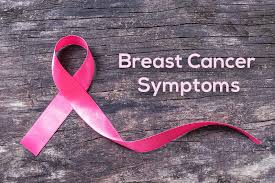

**OVERVIEW**

In this application, I will explore a dataset from Kaggle. The dataset contained information on 569 patient of Wisconsin (Diagnostic). My goal is to understand what factors make a cancer Malignment or Benign.

### CRISP-DM Framework

<center>
    <img src = crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.

### Business Understanding

From a business perspective, I am tasked with identifying key drivers for detecting Brest Cancer.  In the CRISP-DM overview, I am asked to convert this business framing to a data problem definition. Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

### Load the data and analyze the data frame

In [75]:
!pip install ucimlrepo

In [76]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 
  
# metadata 
print(breast_cancer_wisconsin_diagnostic.metadata) 
  
# variable information 
print(breast_cancer_wisconsin_diagnostic.variables)

{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier, Lasso
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
import time
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, recall_score, precision_score
import seaborn as sns
import numpy as np
from sklearn.inspection import permutation_importance

#### Change the target `M` to True and `B` to False

In [79]:
y['Diagnosis'] = y['Diagnosis'].replace({'M': True, 'B': False})

#### Encode the target label

In [81]:
y.Diagnosis.unique()
y = y['Diagnosis']
le = LabelEncoder()
y = le.fit_transform(y)

#### Split the data to training and test set

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Create the transformer

In [86]:
num = X.select_dtypes(include=['float64', 'int64']).columns.tolist()

trxfer = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num),
    ]
)

#### Build a simple Regression Model

In [89]:
simpleLRPipeline = Pipeline([
        ('preprocessor', trxfer),
        ('lr', LogisticRegression())
    ])

simpleLRPipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['radius1', 'texture1',
                                                   'perimeter1', 'area1',
                                                   'smoothness1',
                                                   'compactness1', 'concavity1',
                                                   'concave_points1',
                                                   'symmetry1',
                                                   'fractal_dimension1',
                                                   'radius2', 'texture2',
                                                   'perimeter2', 'area2',
                                                   'smoothness2',
                                                   'compactness2', 'concavity2',
                                                   'concave_points2',
                                                   'symmetry2',
                                                   'fractal_dimension2',
                                                   'radius3', 'texture3',
                                                   'perimeter3', 'area3',
                                                   'smoothness3',
                                                   'compactness3', 'concavity3',
                                                   'concave_points3',
                                                   'symmetry3',
                                                   'fractal_dimension3'])])),
                ('lr', LogisticRegression())])

#### Calculate the accurary, precision and recall for the simple model

In [91]:
preds = simpleLRPipeline.predict(X_test)
accuracy = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds)
recall = recall_score(y_test, preds)
print(f'Accuracy: {accuracy: .2f}\nPrecision: {precision: .2f}\nRecall: {recall: .2f}')

Accuracy:  0.97
Precision:  0.98
Recall:  0.95


#### Create multiple model without hyper-parameter, find the accurary, precision and recall of model. Display Confusion Matrix of the model on test set.

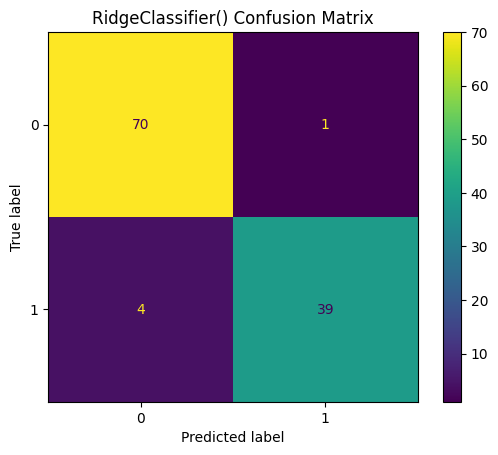

ridge 0.006796836853027344 0.967032967032967 0.956140350877193 1.0 0.975 0.9069767441860465 0.9069767441860465


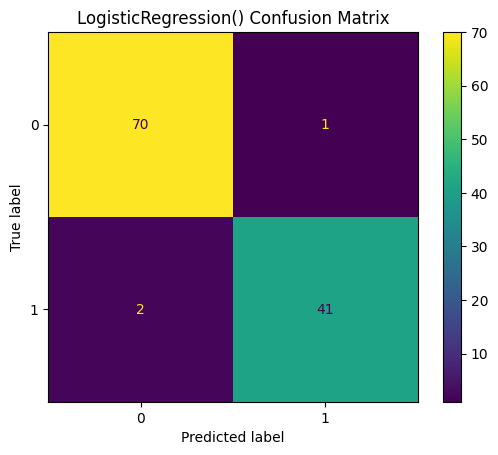

logistic 0.018342256546020508 0.9868131868131869 0.9736842105263158 0.9880239520958084 0.9761904761904762 0.9534883720930233 0.9534883720930233


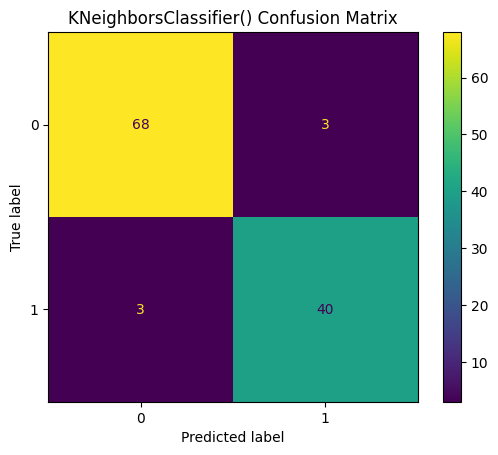

knn 0.006738424301147461 0.9802197802197802 0.9473684210526315 1.0 0.9302325581395349 0.9302325581395349 0.9302325581395349


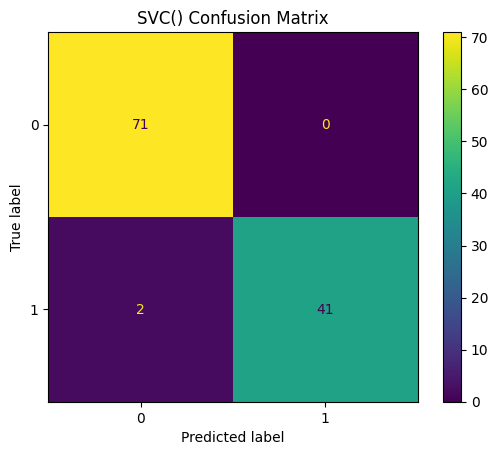

svc 0.010216712951660156 0.989010989010989 0.9824561403508771 1.0 1.0 0.9534883720930233 0.9534883720930233


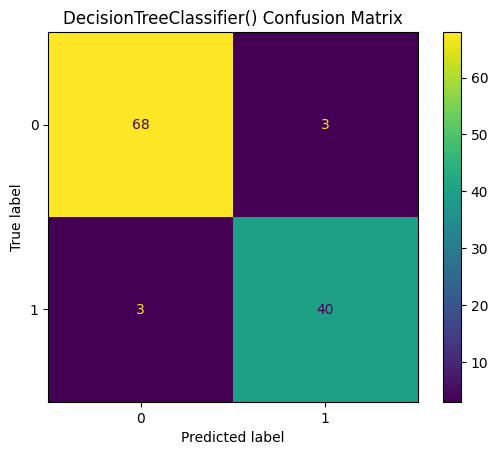

decisiontree 0.016333818435668945 1.0 0.9473684210526315 1.0 0.9302325581395349 0.9302325581395349 0.9302325581395349


In [93]:
defaultModels = {
    'ridge': (RidgeClassifier()),
    'logistic': (LogisticRegression()),
    'knn': (KNeighborsClassifier()),
    'svc': (SVC()),
    'decisiontree': (DecisionTreeClassifier())
}

defaultResults = []

for name, (model) in defaultModels.items():
    # Create a pipeline
    pipeline = Pipeline([
        ('preprocessor', trxfer),
        (name, model)
    ])
    # Fit the model and time it
    start_time = time.time()
    pipeline.fit(X_train, y_train)
    fit_time = (time.time() - start_time)
    
    y_train_predictions = pipeline.predict(X_train)
    y_test_predictions = pipeline.predict(X_test)

    train_accuracy = accuracy_score(y_train, y_train_predictions)
    test_accuracy = accuracy_score(y_test, y_test_predictions)
    train_precision = precision_score(y_train, y_train_predictions)
    test_precision = precision_score(y_test, y_test_predictions)
    train_recall = recall_score(y_test, y_test_predictions)
    test_recall = recall_score(y_test, y_test_predictions)

    cm = confusion_matrix(y_test, y_test_predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    disp.ax_.set_title(str(model) + " Confusion Matrix")
    plt.show()

    print (name, fit_time, train_accuracy, test_accuracy, train_precision, test_precision, train_recall, test_recall)
    #print(model.coef_)
    # Append the results
    defaultResults.append([name, fit_time, train_accuracy, test_accuracy, train_precision, test_precision, train_recall, test_recall])


In [94]:
defaultResults_df = pd.DataFrame(defaultResults, columns=['model', 'fit time','train accuracy', 'test accuracy', 'train precision', 'test precision', 'train recall', 'test recall'])
defaultResults_df.set_index('model', inplace=True)
defaultResults_df

,fit time,train accuracy,test accuracy,train precision,test precision,train recall,test recall
model,,,,,,,
ridge,0.006797,0.967033,0.956140,1.000000,0.975000,0.906977,0.906977
logistic,0.018342,0.986813,0.973684,0.988024,0.976190,0.953488,0.953488
knn,0.006738,0.980220,0.947368,1.000000,0.930233,0.930233,0.930233
svc,0.010217,0.989011,0.982456,1.000000,1.000000,0.953488,0.953488
decisiontree,0.016334,1.000000,0.947368,1.000000,0.930233,0.930233,0.930233


#### Create multiple model with hyper-parameter, find the accurary, precision and recall of model. Display Confusion Matrix of the model on test set.

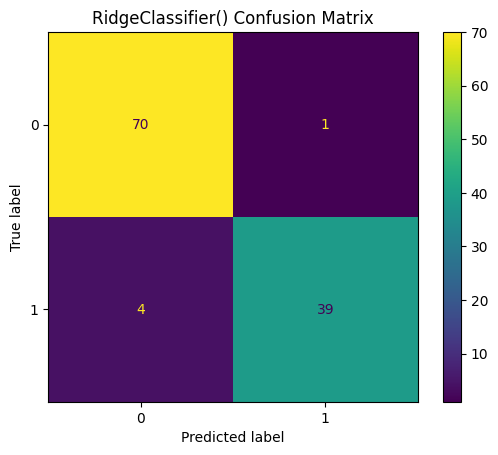

ridge 0.22943012714385985 0.967032967032967 0.956140350877193 {'ridge__alpha': 1.0} 1.0 0.975 0.9302325581395349 0.9069767441860465


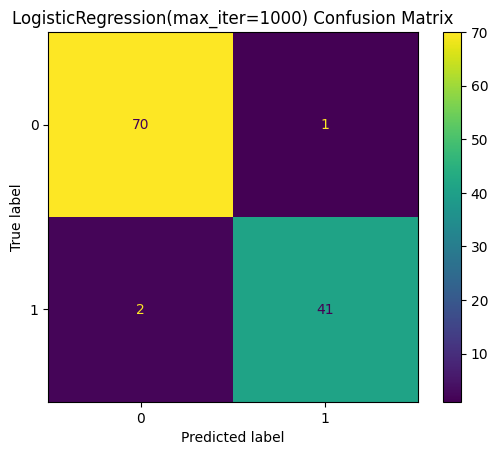

logistic 0.016426348686218263 0.9868131868131869 0.9736842105263158 {'logistic__C': 1.0} 0.9880239520958084 0.9761904761904762 0.9302325581395349 0.9534883720930233


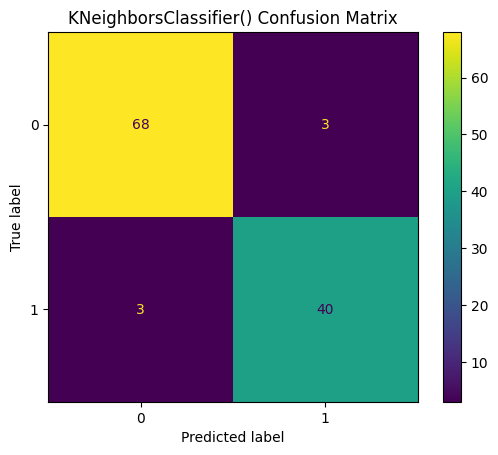

knn 0.01742243766784668 0.9802197802197802 0.9473684210526315 {'knn__n_neighbors': 5} 1.0 0.9302325581395349 0.9302325581395349 0.9302325581395349


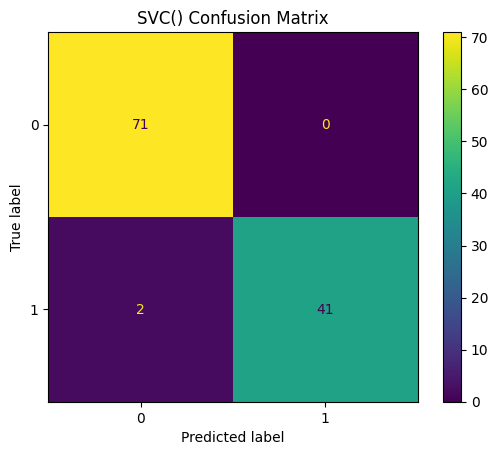

svc 0.012376093864440918 0.9824175824175824 0.9824561403508771 {'svc__C': 0.1, 'svc__kernel': 'linear'} 0.9878787878787879 1.0 0.9302325581395349 0.9534883720930233


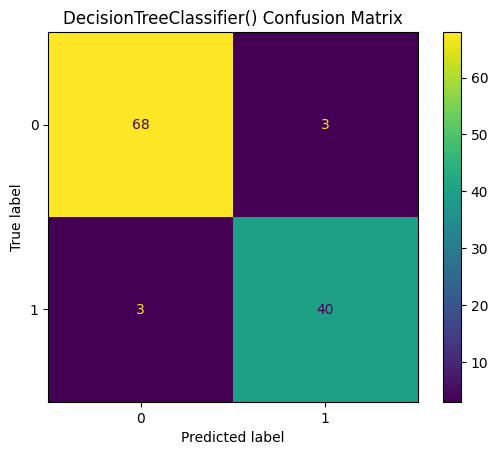

decisiontree 0.018834137916564943 0.9956043956043956 0.9473684210526315 {'decisiontree__max_depth': 5} 1.0 0.9302325581395349 0.9302325581395349 0.9302325581395349


In [96]:
ridge_hyper = {'ridge__alpha': 10**np.linspace(-5,4,10)}
logistic_hyper = {'logistic__C': 10**np.linspace(-5,4,10)}
knn_hyper = {'knn__n_neighbors': list(range(1, 30, 1))}
decisiontree_hyper = {'decisiontree__max_depth': [5, 10, 15,20,25,30,35,40,45,50]}

models = {
    'ridge': (RidgeClassifier(), ridge_hyper),
    'logistic': (LogisticRegression(max_iter=1000), logistic_hyper),
    'knn': (KNeighborsClassifier(), knn_hyper),
    'svc': (SVC(), {'svc__C': 10**np.linspace(-5,4,10), 'svc__kernel': ['linear', 'rbf']}),
    'decisiontree': (DecisionTreeClassifier(), decisiontree_hyper )
}

results = []
best_models = []
for name, (model, params) in models.items():
    # Create a pipeline
    pipeline = Pipeline([
        ('preprocessor', trxfer),
        (name, model)
    ])
    # Perform grid search
    grid_search = GridSearchCV(pipeline, param_grid=params, cv=5, n_jobs=-1)

    # Fit the model and time it
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    fit_time = (time.time() - start_time) / len(grid_search.cv_results_['mean_fit_time'])

    # Get the best estimator
    best_model = grid_search.best_estimator_
    best_models.append([name,best_model])
    
    # Evaluate on training and test sets
    train_score = best_model.score(X_train, y_train)
    test_score = best_model.score(X_test, y_test)
    
    predictions = best_model.predict(X_test)

    y_train_predictions = best_model.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_predictions)
    test_accuracy = accuracy_score(y_test, predictions)
    train_precision = precision_score(y_train, y_train_predictions)
    test_precision = precision_score(y_test, predictions)
    train_recall = recall_score(y_test, y_test_predictions)
    test_recall = recall_score(y_test, predictions)

    
    cm = confusion_matrix(y_test, predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    disp.ax_.set_title(str(model) + " Confusion Matrix")
    plt.show()
    print (name, fit_time, train_score, test_score, grid_search.best_params_, train_precision,test_precision, train_recall,test_recall )
    
    # Append the results
    results.append([name, fit_time, train_score, test_score, train_precision, test_precision, train_recall,test_recall, grid_search.best_params_])


In [97]:
results_df = pd.DataFrame(results, columns=['model', 'average fit time', 'train score', 'test score',' train precision', 'test precision','train recall','test recall', 'hyper'])
results_df.set_index('model', inplace=True)
results_df

,average fit time,train score,test score,train precision,test precision,train recall,test recall,hyper
model,,,,,,,,
ridge,0.229430,0.967033,0.956140,1.000000,0.975000,0.930233,0.906977,{'ridge__alpha': 1.0}
logistic,0.016426,0.986813,0.973684,0.988024,0.976190,0.930233,0.953488,{'logistic__C': 1.0}
knn,0.017422,0.980220,0.947368,1.000000,0.930233,0.930233,0.930233,{'knn__n_neighbors': 5}
svc,0.012376,0.982418,0.982456,0.987879,1.000000,0.930233,0.953488,"{'svc__C': 0.1, 'svc__kernel': 'linear'}"
decisiontree,0.018834,0.995604,0.947368,1.000000,0.930233,0.930233,0.930233,{'decisiontree__max_depth': 5}


### Coefficients from Ridge Regression

In [102]:
ridge_pipe = best_models[0][1]
ridge_model = ridge_pipe['ridge']
coefficients_ridge = ridge_model.coef_[0]
coefficients_ridge_df = pd.DataFrame({'feature': X_train.columns, 'coefficient': coefficients_ridge})
coefficients_ridge_df = coefficients_ridge_df.sort_values(by='coefficient', ascending=False)
print("\nCoefficients from Ridge Regression:")
print(coefficients_ridge_df)


Coefficients from Ridge Regression:
               feature  coefficient
20             radius3     0.753815
10             radius2     0.423402
7      concave_points1     0.331412
26          concavity3     0.235878
17     concave_points2     0.183654
0              radius1     0.174355
6           concavity1     0.165991
28           symmetry3     0.149681
25        compactness3     0.149268
21            texture3     0.128296
2           perimeter1     0.125843
14         smoothness2     0.107043
29  fractal_dimension3     0.092766
9   fractal_dimension1     0.041630
1             texture1     0.022354
24         smoothness3     0.016906
4          smoothness1    -0.016865
11            texture2    -0.019902
19  fractal_dimension2    -0.025047
18           symmetry2    -0.025607
8            symmetry1    -0.034602
15        compactness2    -0.075178
12          perimeter2    -0.077589
27     concave_points3    -0.089576
22          perimeter3    -0.109582
3                area1    -

### Coefficients from Logistic Regression

In [108]:
logistic_pipe = best_models[1][1]
logistic_model = logistic_pipe['logistic']
coefficients_logistic = logistic_model.coef_[0]
coefficients_logistic_df = pd.DataFrame({'feature': X_train.columns, 'coefficient': coefficients_logistic})
coefficients_logistic_df = coefficients_logistic_df.sort_values(by='coefficient', ascending=False)
print("\nCoefficients from Logistic Regression:")
print(coefficients_logistic_df)


Coefficients from Logistic Regression:
               feature  coefficient
21            texture3     1.350606
10             radius2     1.268178
28           symmetry3     1.208200
7      concave_points1     1.119804
26          concavity3     0.943053
13               area2     0.907186
20             radius3     0.879840
23               area3     0.841846
6           concavity1     0.801458
27     concave_points3     0.778217
12          perimeter2     0.610583
22          perimeter3     0.589453
24         smoothness3     0.544170
3                area1     0.465210
0              radius1     0.431904
2           perimeter1     0.393432
1             texture1     0.387326
14         smoothness2     0.313307
17     concave_points2     0.311300
29  fractal_dimension3     0.157414
4          smoothness1     0.071667
25        compactness3    -0.016110
9   fractal_dimension1    -0.075921
16          concavity2    -0.175275
11            texture2    -0.188877
8            symmetry1  

### Permutation Importance from KNN

In [110]:
result_knn = permutation_importance(best_models[2][1], X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_importances_knn = pd.DataFrame({'feature': X_test.columns, 'importance': result_knn.importances_mean})
perm_importances_knn = perm_importances_knn.sort_values(by='importance', ascending=False)
print("\nPermutation Importance from KNN:")
print(perm_importances_knn)



Permutation Importance from KNN:
               feature  importance
16          concavity2    0.000000
24         smoothness3   -0.000877
13               area2   -0.001754
12          perimeter2   -0.001754
10             radius2   -0.001754
29  fractal_dimension3   -0.002632
21            texture3   -0.002632
9   fractal_dimension1   -0.002632
14         smoothness2   -0.003509
23               area3   -0.003509
20             radius3   -0.003509
2           perimeter1   -0.004386
6           concavity1   -0.005263
8            symmetry1   -0.005263
25        compactness3   -0.005263
27     concave_points3   -0.005263
22          perimeter3   -0.005263
0              radius1   -0.005263
3                area1   -0.005263
1             texture1   -0.007018
7      concave_points1   -0.007018
19  fractal_dimension2   -0.007895
15        compactness2   -0.007895
4          smoothness1   -0.007895
17     concave_points2   -0.009649
26          concavity3   -0.010526
11            texture

### Permutation Importance from SVC

In [112]:
# Feature importance using permutation for SVC
result_svc = permutation_importance(best_models[3][1], X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_importances_svc = pd.DataFrame({'feature': X_test.columns, 'importance': result_svc.importances_mean})
perm_importances_svc = perm_importances_svc.sort_values(by='importance', ascending=False)
print("\nPermutation Importance from SVC:")
print(perm_importances_svc)


Permutation Importance from SVC:
               feature  importance
7      concave_points1    0.017544
28           symmetry3    0.014035
24         smoothness3    0.011404
20             radius3    0.011404
15        compactness2    0.010526
6           concavity1    0.009649
23               area3    0.009649
27     concave_points3    0.009649
10             radius2    0.009649
22          perimeter3    0.009649
13               area2    0.007895
21            texture3    0.007895
12          perimeter2    0.007895
11            texture2    0.007895
26          concavity3    0.007018
3                area1    0.004386
18           symmetry2    0.003509
0              radius1    0.003509
29  fractal_dimension3    0.003509
5         compactness1    0.002632
2           perimeter1    0.002632
14         smoothness2    0.002632
19  fractal_dimension2    0.000877
9   fractal_dimension1    0.000877
17     concave_points2    0.000000
16          concavity2    0.000000
8            symmetry

### Feature Importance from Decision Tree

In [116]:
tree_pipe = best_models[4][1]
tree_model = tree_pipe['decisiontree']
importances_tree = tree_model.feature_importances_
feature_importance_tree_df = pd.DataFrame({'feature': X_train.columns, 'importance': importances_tree})
feature_importance_tree_df = feature_importance_tree_df.sort_values(by='importance', ascending=False)
print("\nFeature Importance from Decision Tree:")
print(feature_importance_tree_df)



Feature Importance from Decision Tree:
               feature  importance
7      concave_points1    0.703696
27     concave_points3    0.066816
1             texture1    0.059516
20             radius3    0.053228
22          perimeter3    0.052408
19  fractal_dimension2    0.018884
17     concave_points2    0.016214
13               area2    0.012195
24         smoothness3    0.009397
18           symmetry2    0.006387
14         smoothness2    0.001259
0              radius1    0.000000
21            texture3    0.000000
25        compactness3    0.000000
26          concavity3    0.000000
28           symmetry3    0.000000
23               area3    0.000000
15        compactness2    0.000000
16          concavity2    0.000000
12          perimeter2    0.000000
11            texture2    0.000000
10             radius2    0.000000
9   fractal_dimension1    0.000000
8            symmetry1    0.000000
6           concavity1    0.000000
5         compactness1    0.000000
4          smoo

### Feature Importances and Coefficients from Various Models

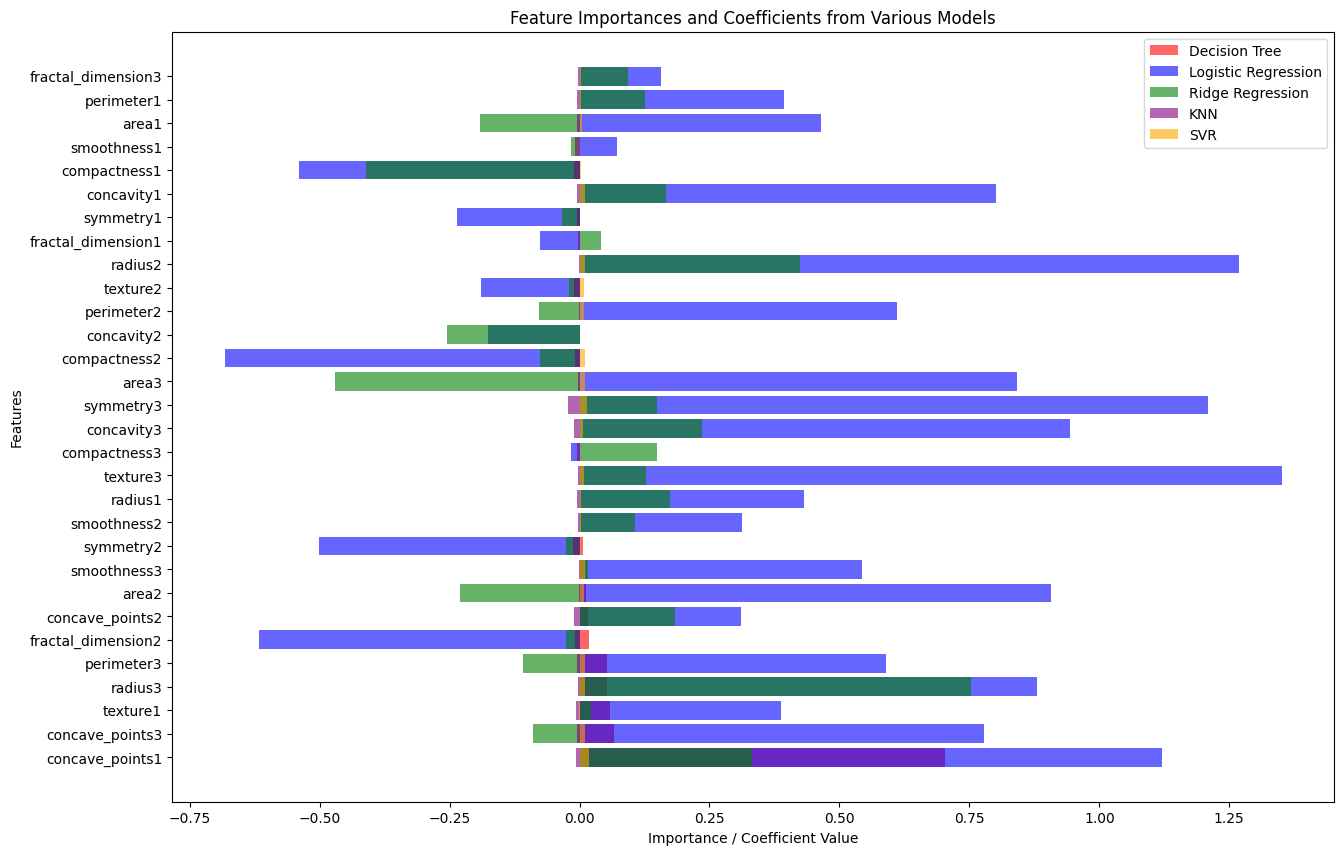

In [118]:
#Plotting the feature importances and coefficients
plt.figure(figsize=(15, 10))

# Plot Decision Tree feature importance
plt.barh(feature_importance_tree_df['feature'], feature_importance_tree_df['importance'], color='red', alpha=0.6, label='Decision Tree')

# Plot Logistic Regression coefficients
plt.barh(coefficients_logistic_df['feature'], coefficients_logistic_df['coefficient'], color='blue', alpha=0.6, label='Logistic Regression')

# Plot Ridge Regression coefficients
plt.barh(coefficients_ridge_df['feature'], coefficients_ridge_df['coefficient'], color='green', alpha=0.6, label='Ridge Regression')

# Plot KNN permutation importance
plt.barh(perm_importances_knn['feature'], perm_importances_knn['importance'], color='purple', alpha=0.6, label='KNN')

# Plot SVR permutation importance
plt.barh(perm_importances_svr['feature'], perm_importances_svr['importance'], color='orange', alpha=0.6, label='SVR')

plt.xlabel('Importance / Coefficient Value')
plt.ylabel('Features')
plt.title('Feature Importances and Coefficients from Various Models')
plt.legend()
plt.show()

### Future enhancement with Deep Neural Network

In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import plot_model

In [121]:
complex_model = Sequential([
    Dense(50,activation='relu'),
    Dense(10,activation='relu'),
    Dense(1, activation='sigmoid')
])
complex_model.compile(optimizer='rmsprop',loss='binary_crossentropy',metrics=['accuracy'])
complex_model.fit(X_train,y_train,validation_data=(X_test,y_test), epochs=20,batch_size=10, verbose=0)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9184 - loss: 0.1202
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9200 - loss: 0.2202 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


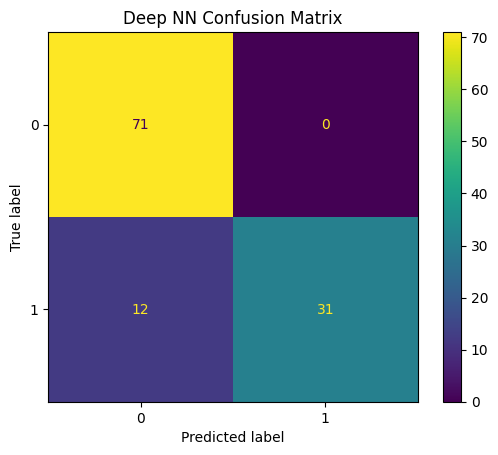

In [122]:
dnn_test_result = complex_model.evaluate(X_test,y_test)
dnn_train_result = complex_model.evaluate(X_train,y_train)
dnn_predictions = complex_model.predict(X_test)
dnn_train_predictions = complex_model.predict(X_train)
y_train_num = np.where(dnn_train_predictions < 0.8, 0, 1)
y_test_num = np.where(dnn_predictions < 0.8, 0, 1)

dnn_train_accuracy = accuracy_score(y_train, y_train_num)
dnn_test_accuracy = accuracy_score(y_test, y_test_num)

dnn_train_precision = precision_score(y_train, y_train_num)
dnn_test_precision = precision_score(y_test, y_test_num)

dnn_train_recall = recall_score(y_train, y_train_num)
dnn_test_recall = recall_score(y_test, y_test_num)

cm = confusion_matrix(y_test, y_test_num)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
disp.ax_.set_title("Deep NN Confusion Matrix")
plt.show()

In [123]:
print (dnn_train_accuracy,dnn_test_accuracy, dnn_train_precision,  dnn_test_precision,dnn_train_recall, dnn_test_recall )

0.8505494505494505 0.8947368421052632 0.9902912621359223 1.0 0.6035502958579881 0.7209302325581395
